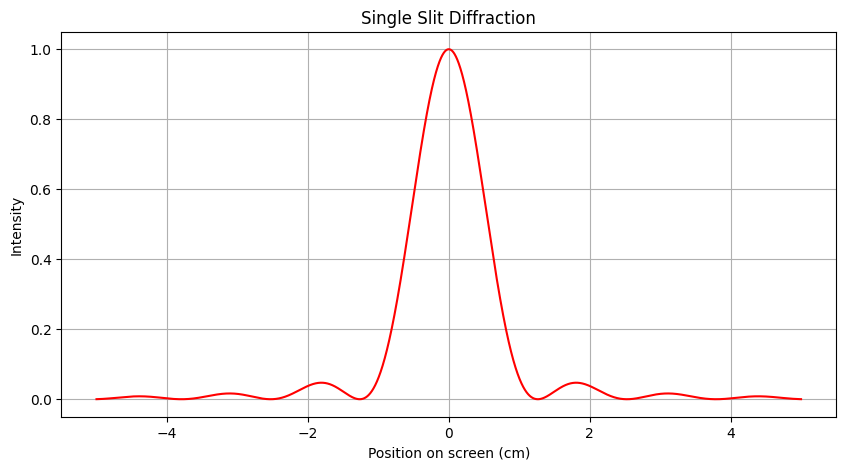

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Single slit diffraction
wavelength = 632e-9   # লাল laser
slit_width = 0.05e-3  # আগে ছিল 0.1mm, এখন 0.05mm
L = 1.0               # পর্দা ১ মিটার দূরে

# পর্দায় position
x = np.linspace(-0.05, 0.05, 10000)

# angle
theta = np.arctan(x / L)

# diffraction pattern
beta = (np.pi * slit_width * np.sin(theta)) / wavelength
I = (np.sinc(beta / np.pi))**2

plt.figure(figsize=(10, 5))
plt.plot(x * 100, I, color='red')
plt.title("Single Slit Diffraction")
plt.xlabel("Position on screen (cm)")
plt.ylabel("Intensity")
plt.grid(True)
plt.show()

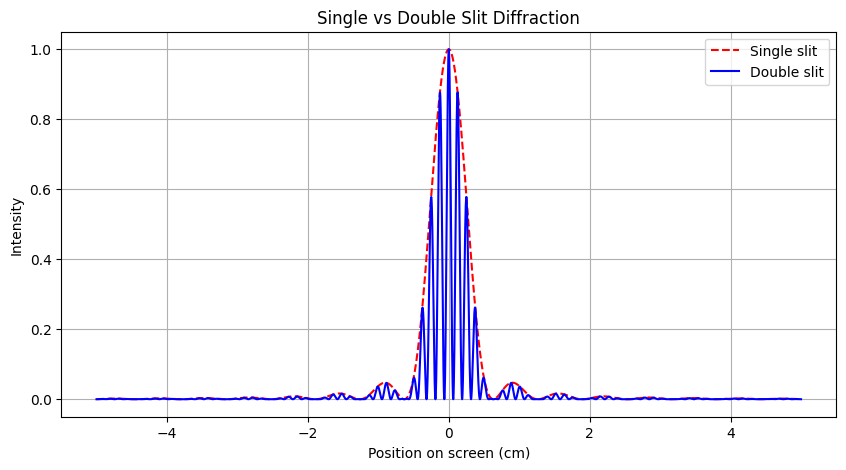

In [3]:
import numpy as np
import matplotlib.pyplot as plt

wavelength = 632e-9
slit_width = 0.1e-3
slit_separation = 0.5e-3  # দুটো ফাঁকের দূরত্ব
L = 1.0

x = np.linspace(-0.05, 0.05, 10000)
theta = np.arctan(x / L)

# Single slit envelope
beta = (np.pi * slit_width * np.sin(theta)) / wavelength
single = (np.sinc(beta / np.pi))**2

# Double slit interference
delta = (np.pi * slit_separation * np.sin(theta)) / wavelength
double = single * (np.cos(delta))**2

plt.figure(figsize=(10, 5))
plt.plot(x * 100, single, color='red', linestyle='--', label='Single slit')
plt.plot(x * 100, double, color='blue', label='Double slit')
plt.title("Single vs Double Slit Diffraction")
plt.xlabel("Position on screen (cm)")
plt.ylabel("Intensity")
plt.legend()
plt.grid(True)
plt.show()

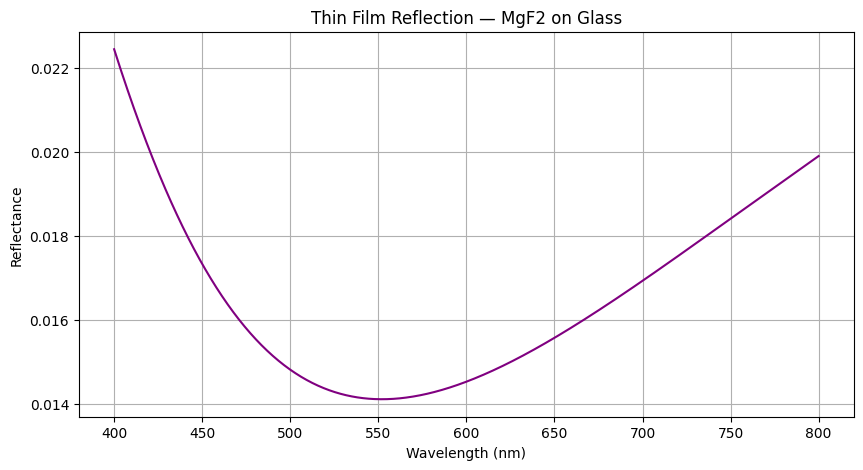

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# pip install tmm আগে install করো
# terminal-এ লেখো: pip install tmm

import tmm

# আলোর wavelength
wavelength = np.linspace(400e-9, 800e-9, 1000)

# Film structure
# বাতাস → MgF2 coating → Glass
n_air = 1.0
n_film = 1.38    # MgF2 refractive index
n_glass = 1.5

# Film thickness
d = 100e-9       # 100nm

# Reflection calculate
R = []
for lam in wavelength:
    result = tmm.coh_tmm('s',
        [n_air, n_film, n_glass],
        [np.inf, d, np.inf],
        0,
        lam)
    R.append(result['R'])

plt.figure(figsize=(10, 5))
plt.plot(wavelength * 1e9, R, color='purple')
plt.title("Thin Film Reflection — MgF2 on Glass")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Reflectance")
plt.grid(True)
plt.show()